In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [47]:
df = pd.read_csv("food_carbon_footprint_dataset.csv")

In [49]:
df.columns

Index(['Date', 'Food Item', 'Quantity Donated', 'Quantity Requested',
       'Expiration Date', 'Seasonality', 'Holidays', 'Market Prices',
       'Disaster Events', 'Recipient Preferences', 'Delivery Time',
       'Food Waste Rate', 'Distance Traveled (km)', 'Transportation Mode',
       'Storage Duration (days)', 'Energy Used in Storage (kWh)',
       'Carbon Footprint', 'Fuel Type', 'Logistics Cost', 'Packaging Type',
       'Refrigeration Required'],
      dtype='object')

In [51]:
df.head()

,Date,Food Item,Quantity Donated,Quantity Requested,Expiration Date,Seasonality,Holidays,Market Prices,Disaster Events,Recipient Preferences,...,Food Waste Rate,Distance Traveled (km),Transportation Mode,Storage Duration (days),Energy Used in Storage (kWh),Carbon Footprint,Fuel Type,Logistics Cost,Packaging Type,Refrigeration Required
0,2022-01-31,Fish,489.0,NaN,2022-09-05,NaN,0.0,10.023852,2.0,10.0,...,0.067396,388.929579,Electric Vehicle,26.0,45.415261,11.632276,Electric,266.464789,Plastic,0.0
1,2022-12-30,Meat,NaN,184.0,2023-05-07,1.006744,1.0,1.971274,2.0,10.0,...,0.080328,471.156970,NaN,18.0,25.950876,10.690672,Electric,291.578485,Plastic,0.0
2,2021-05-10,Canned Food,499.0,507.0,2022-02-20,NaN,1.0,11.460630,0.0,6.0,...,0.056987,216.792529,Train,29.0,38.966433,7.641280,Diesel,NaN,NaN,0.0
3,2022-07-18,Fish,10.0,11.0,2023-06-21,0.978526,1.0,8.539173,0.0,9.0,...,0.088582,79.952998,Drone,17.0,11.944138,NaN,Electric,73.976499,Biodegradable,0.0
4,2022-02-04,Milk,18.0,66.0,2022-07-03,0.990863,1.0,18.640839,NaN,3.0,...,0.206517,205.339766,Drone,2.0,1.976187,4.479733,Electric,106.669883,Glass,0.0


In [53]:
df.describe()

,Quantity Donated,Quantity Requested,Seasonality,Holidays,Market Prices,Disaster Events,Recipient Preferences,Delivery Time,Food Waste Rate,Distance Traveled (km),Storage Duration (days),Energy Used in Storage (kWh),Carbon Footprint,Logistics Cost,Refrigeration Required
count,18958.000000,18932.000000,18039.000000,19482.000000,19458.000000,19639.000000,17906.000000,19450.000000,19350.000000,18967.000000,19751.000000,18607.000000,18639.000000,18601.000000,18306.000000
mean,254.275926,253.349303,1.105009,0.507494,11.517202,0.373797,5.490897,4.969934,0.065652,253.622207,15.033922,27.217174,10.707624,160.925204,0.300666
std,141.464677,152.983371,0.343214,0.499957,7.249865,0.881829,2.881006,3.257975,0.045070,142.553742,8.391621,24.261943,12.400490,73.642304,0.458560
min,10.000000,-88.000000,0.800171,0.000000,0.810228,0.000000,1.000000,0.067086,0.010009,5.002365,1.000000,0.500643,0.395089,5.528969,0.000000
25%,131.000000,130.000000,0.911409,0.000000,5.896135,0.000000,3.000000,2.366839,0.034777,131.565314,8.000000,10.170539,4.056601,100.033240,0.000000
50%,254.000000,255.000000,1.024251,1.000000,10.856802,0.000000,5.000000,4.603124,0.059144,255.006700,15.000000,20.415701,5.974905,160.969041,0.000000
75%,378.000000,375.000000,1.133313,1.000000,15.827345,0.000000,8.000000,6.914504,0.084055,375.213379,22.000000,36.121576,9.618444,222.598944,1.000000
max,499.000000,595.000000,2.683474,1.000000,51.690079,5.000000,10.000000,16.502218,0.296925,499.991577,29.000000,144.978494,64.816683,347.378584,1.000000


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          19020 non-null  object 
 1   Food Item                     19433 non-null  object 
 2   Quantity Donated              18958 non-null  float64
 3   Quantity Requested            18932 non-null  float64
 4   Expiration Date               19357 non-null  object 
 5   Seasonality                   18039 non-null  float64
 6   Holidays                      19482 non-null  float64
 7   Market Prices                 19458 non-null  float64
 8   Disaster Events               19639 non-null  float64
 9   Recipient Preferences         17906 non-null  float64
 10  Delivery Time                 19450 non-null  float64
 11  Food Waste Rate               19350 non-null  float64
 12  Distance Traveled (km)        18967 non-null  float64
 13  T

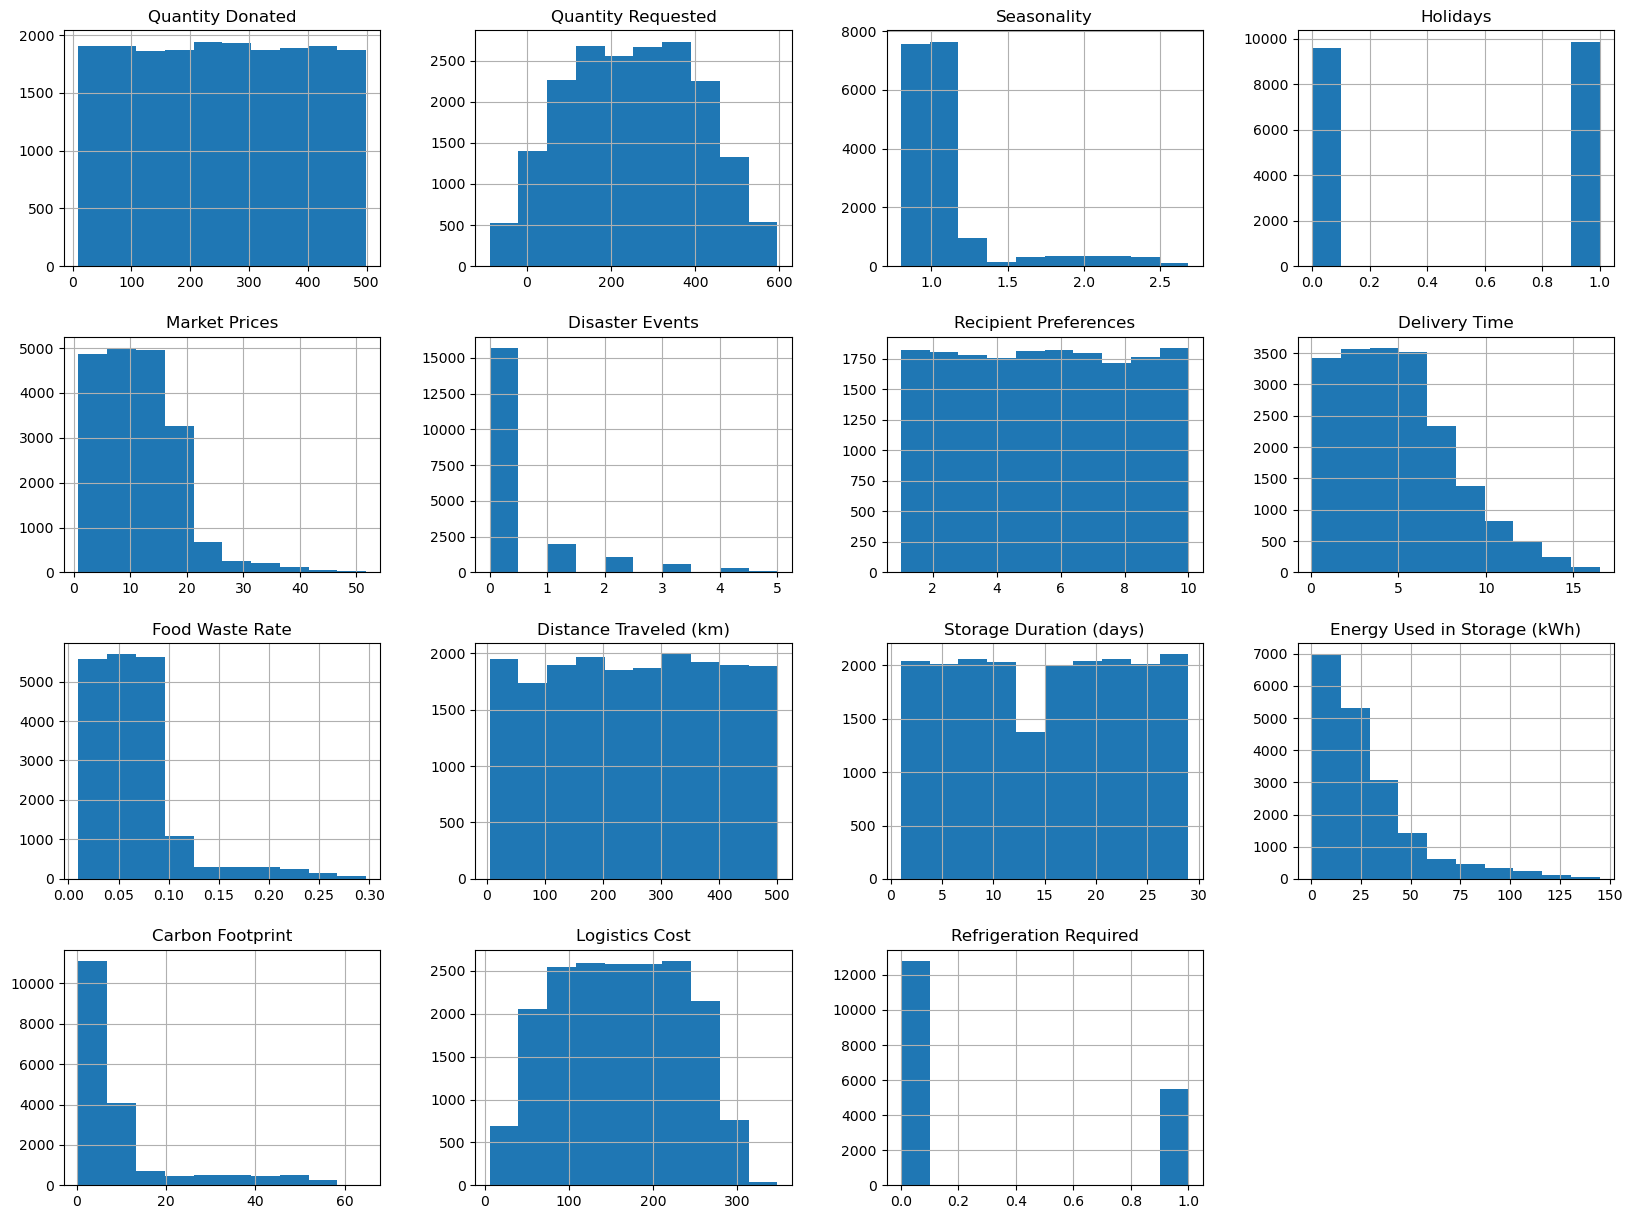

In [57]:
# Displying Histograms
df.hist(figsize=(20,15))
plt.show()

# 1 : **Data Cleaning** 

In [59]:
rows_before, cols_before = df.shape

### **Duplicates :**

In [62]:
print("Number of duplicates :", df.duplicated().sum())

Number of duplicates : 1000


In [64]:
df.drop_duplicates(inplace=True)

In [66]:
print("Number of duplicates:", df.duplicated().sum())

Number of duplicates: 0


### **Missing Values :**

In [68]:
print("Missing Values :", df.isnull().sum())

Missing Values : Date                            1874
Food Item                       1496
Quantity Donated                1936
Quantity Requested              1967
Expiration Date                 1562
Seasonality                     2816
Holidays                        1462
Market Prices                   1470
Disaster Events                 1292
Recipient Preferences           2953
Delivery Time                   1468
Food Waste Rate                 1568
Distance Traveled (km)          1926
Transportation Mode             2854
Storage Duration (days)         1193
Energy Used in Storage (kWh)    2280
Carbon Footprint                2253
Fuel Type                       4918
Logistics Cost                  2279
Packaging Type                  2191
Refrigeration Required          2575
dtype: int64


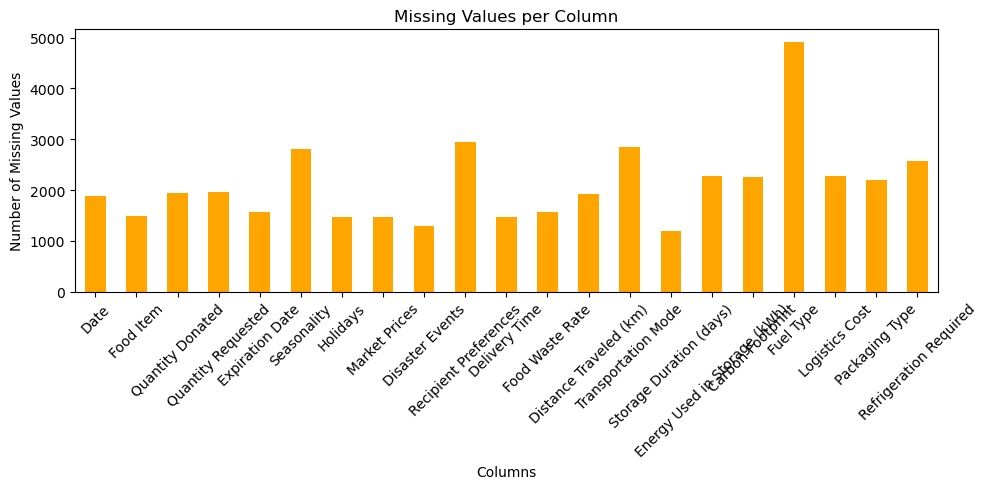

In [70]:
missing = df.isnull().sum()
missing = missing[missing > 0]


missing.plot(kind='bar', color='orange', figsize=(10, 5))
plt.title('Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Defining a threshhold and droping all columns above it :

In [73]:
threshold = 0.6 * len(df)

df = df.dropna(thresh=threshold, axis=1)

 Imputing Missing Values with median :

In [76]:
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].apply(lambda x: x.fillna(x.median()))

In [78]:
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].apply(lambda x: x.fillna(x.mode()[0]))

In [80]:
print("Missing Values :\n", df.isnull().sum())

Missing Values :
 Date                            0
Food Item                       0
Quantity Donated                0
Quantity Requested              0
Expiration Date                 0
Seasonality                     0
Holidays                        0
Market Prices                   0
Disaster Events                 0
Recipient Preferences           0
Delivery Time                   0
Food Waste Rate                 0
Distance Traveled (km)          0
Transportation Mode             0
Storage Duration (days)         0
Energy Used in Storage (kWh)    0
Carbon Footprint                0
Fuel Type                       0
Logistics Cost                  0
Packaging Type                  0
Refrigeration Required          0
dtype: int64


In [82]:
df_cleaned = df

In [84]:
rows_after, cols_after = df_cleaned.shape

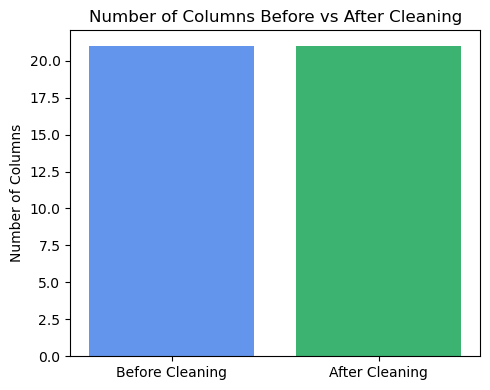

In [86]:
data = {
    'Before Cleaning': [rows_before, cols_before],
    'After Cleaning': [rows_after, cols_after]
}

df_plot = pd.DataFrame(data, index=['Rows', 'Columns'])


# --- Columns Chart ---
plt.figure(figsize=(5, 4))
plt.bar(['Before Cleaning', 'After Cleaning'], [cols_before, cols_after], color=['cornflowerblue', 'mediumseagreen'])
plt.title('Number of Columns Before vs After Cleaning')
plt.ylabel('Number of Columns')
plt.tight_layout()
plt.show()


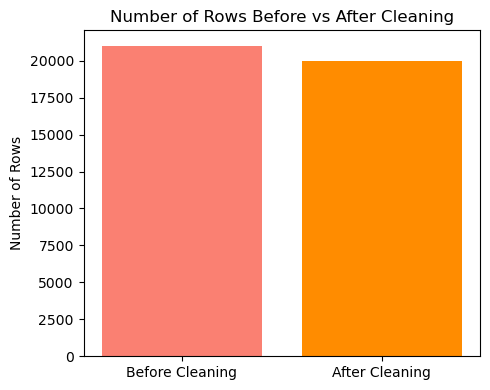

In [88]:
# --- Rows Chart ---
plt.figure(figsize=(5, 4))
plt.bar(['Before Cleaning', 'After Cleaning'], [rows_before, rows_after], color=['salmon', 'darkorange'])
plt.title('Number of Rows Before vs After Cleaning')
plt.ylabel('Number of Rows')
plt.tight_layout()
plt.show()


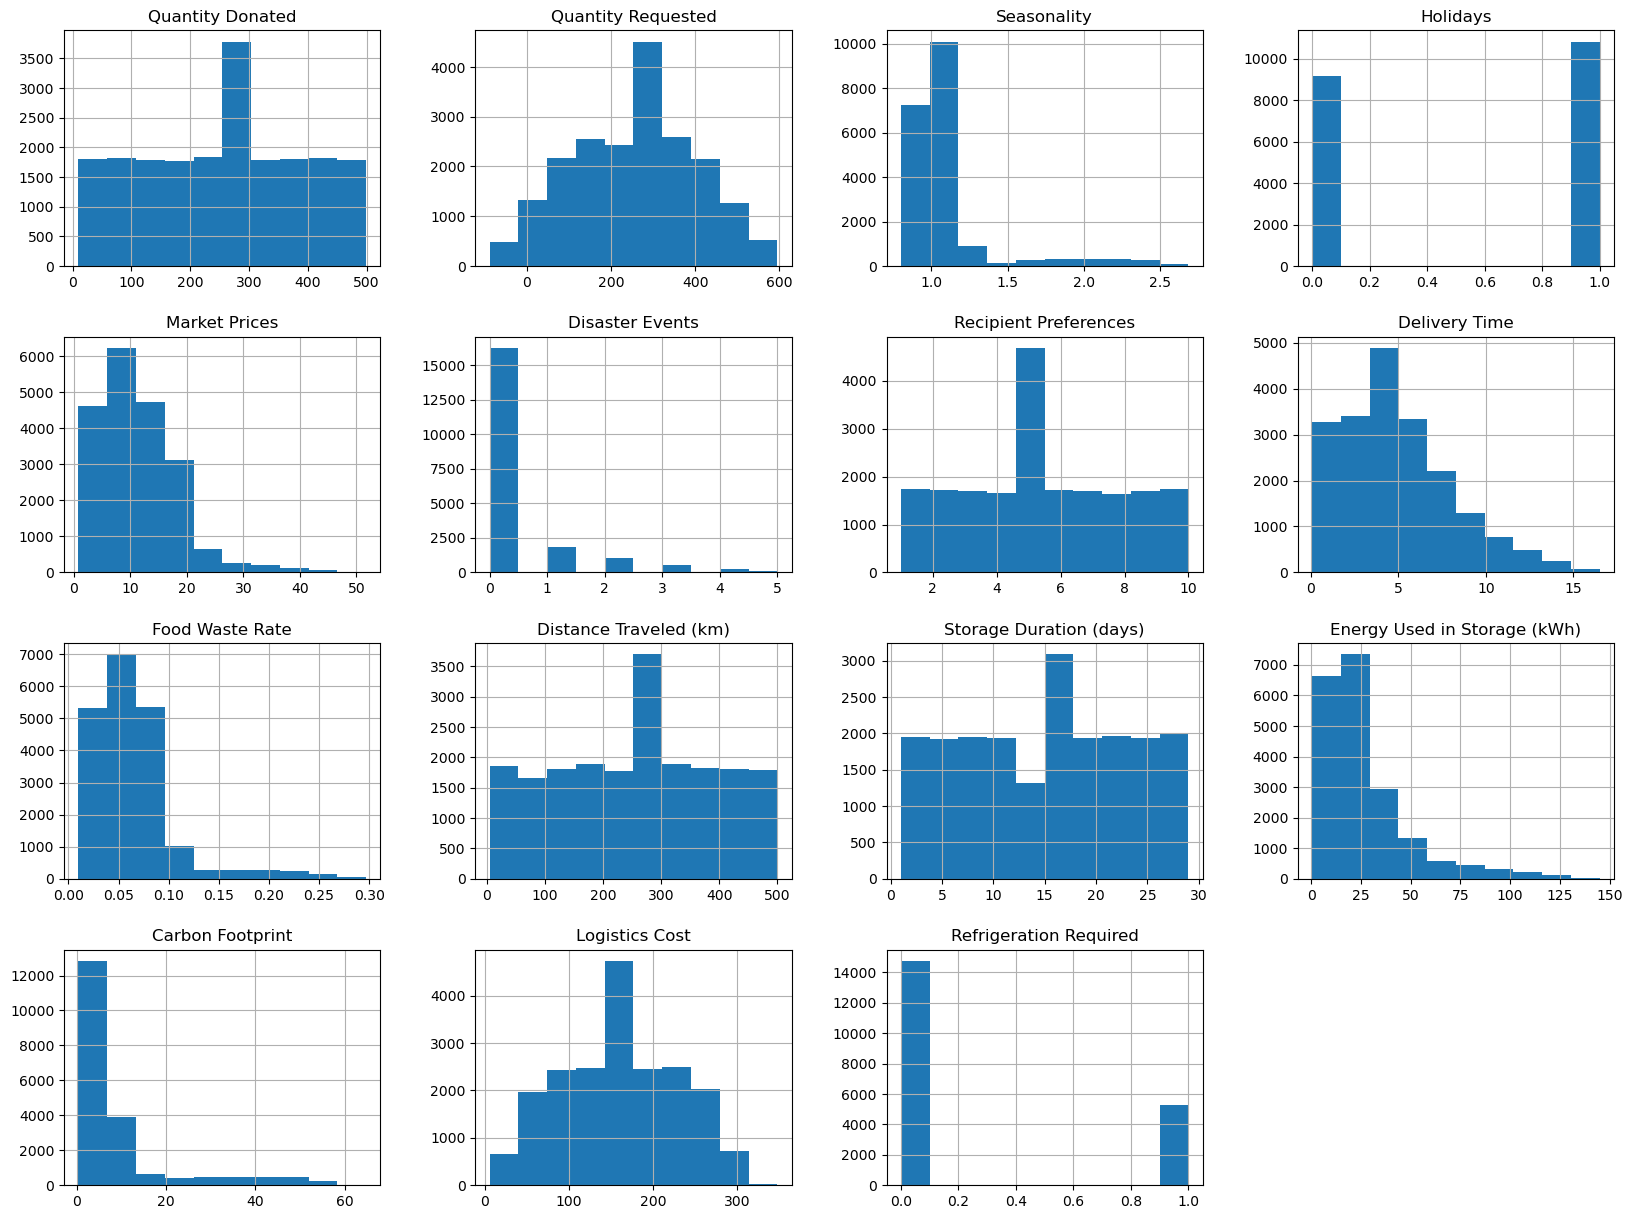

In [90]:
# Displying Histograms
df.hist(figsize=(20,15))
plt.show()

# 

**2 : Dealing with Categorical Values**

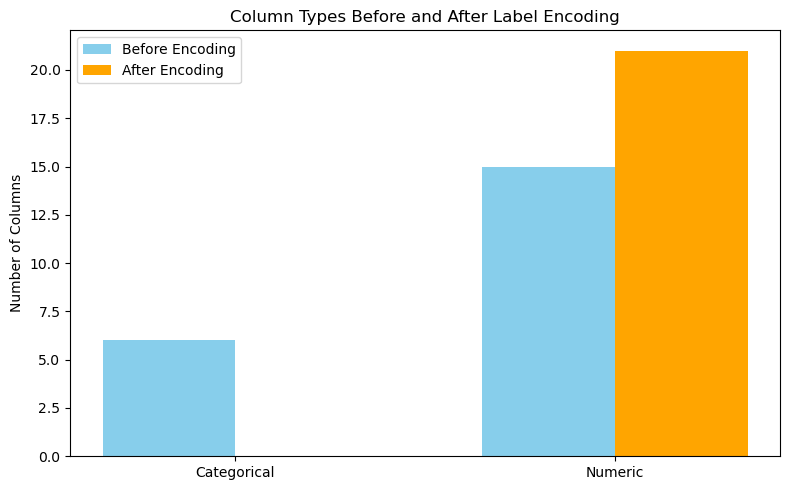

In [92]:
df_original = df.copy()


before_categorical = df_original.select_dtypes(include='object').shape[1]
before_numeric = df_original.select_dtypes(exclude='object').shape[1]


label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le


after_categorical = df.select_dtypes(include='object').shape[1]
after_numeric = df.select_dtypes(exclude='object').shape[1]


labels = ['Categorical', 'Numeric']
before = [before_categorical, before_numeric]
after = [after_categorical, after_numeric]

x = range(len(labels))
bar_width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x, before, width=bar_width, label='Before Encoding', color='skyblue')
plt.bar([i + bar_width for i in x], after, width=bar_width, label='After Encoding', color='orange')

plt.xticks([i + bar_width/2 for i in x], labels)
plt.ylabel('Number of Columns')

plt.title('Column Types Before and After Label Encoding')
plt.legend()
plt.tight_layout()
plt.show()


# **3 : Normalizing numerical features**

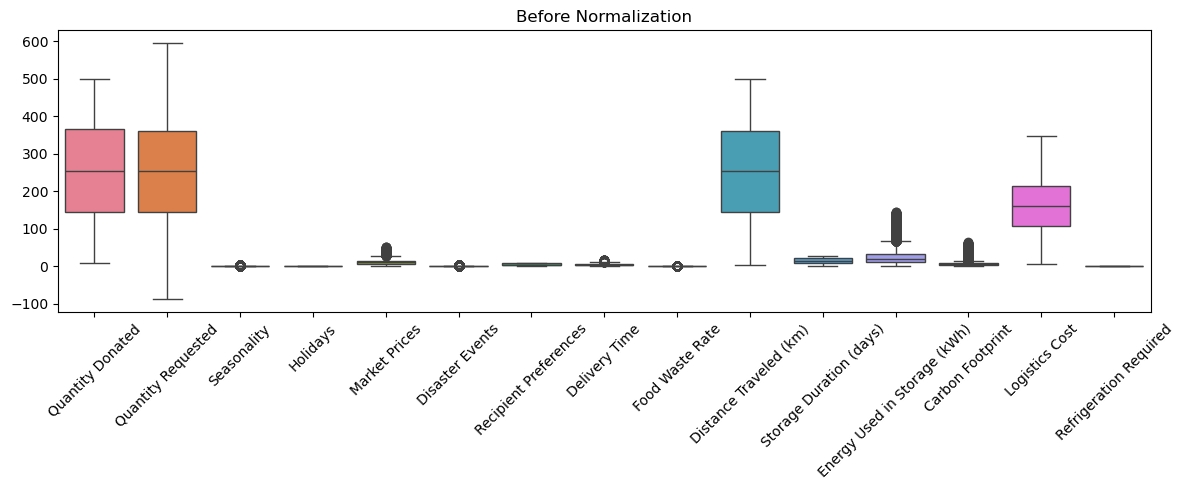

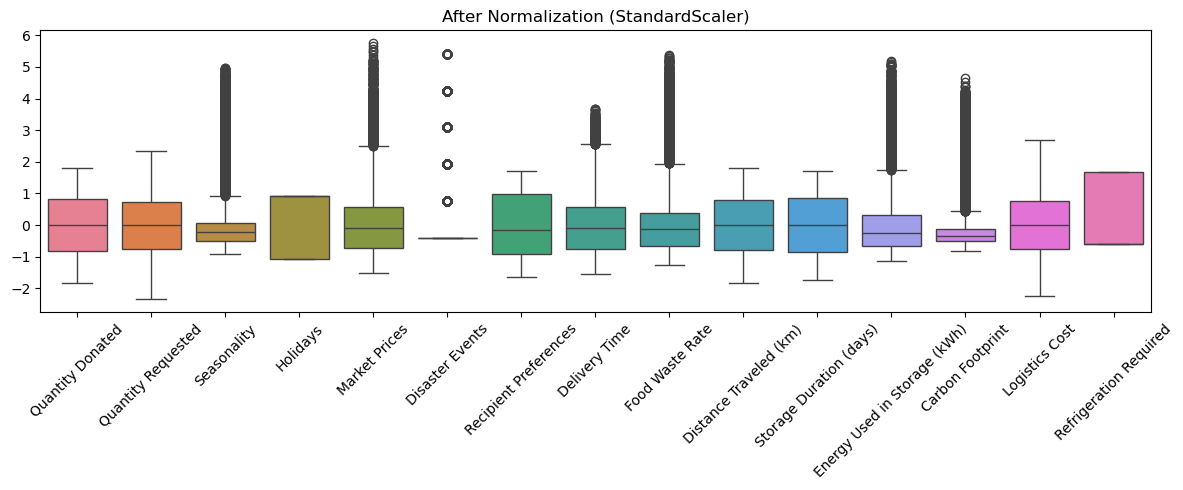

In [94]:
df_before_scaling = df.copy()


scaler = StandardScaler()
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


plt.figure(figsize=(12, 5))
sns.boxplot(data=df_before_scaling[numerical_cols])
plt.title('Before Normalization')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



plt.figure(figsize=(12, 5))
sns.boxplot(data=df[numerical_cols])
plt.title('After Normalization (StandardScaler)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [98]:
file_path = "Cleaned_dataset.csv"
df.to_csv(file_path, index=False)